# **Image Blending from Scratch**
Naive copy · Laplacian pyramid blending · Poisson blending

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("src").resolve()))

import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from config import IMAGE_NAME, GRAD_MIX, NUM_LEVELS, RESULT_DIR, get_offset
from utils import load_img, preprocess_images, display_images
from naive_blend import naive_blend
from laplacian_blend import laplacian_blend
from poisson_blend import poisson_blend

## **Load preview input images**

Confirmed — offset: [43, 54], scale: 0.50x
Scaled source & mask by 0.50x → 212x300


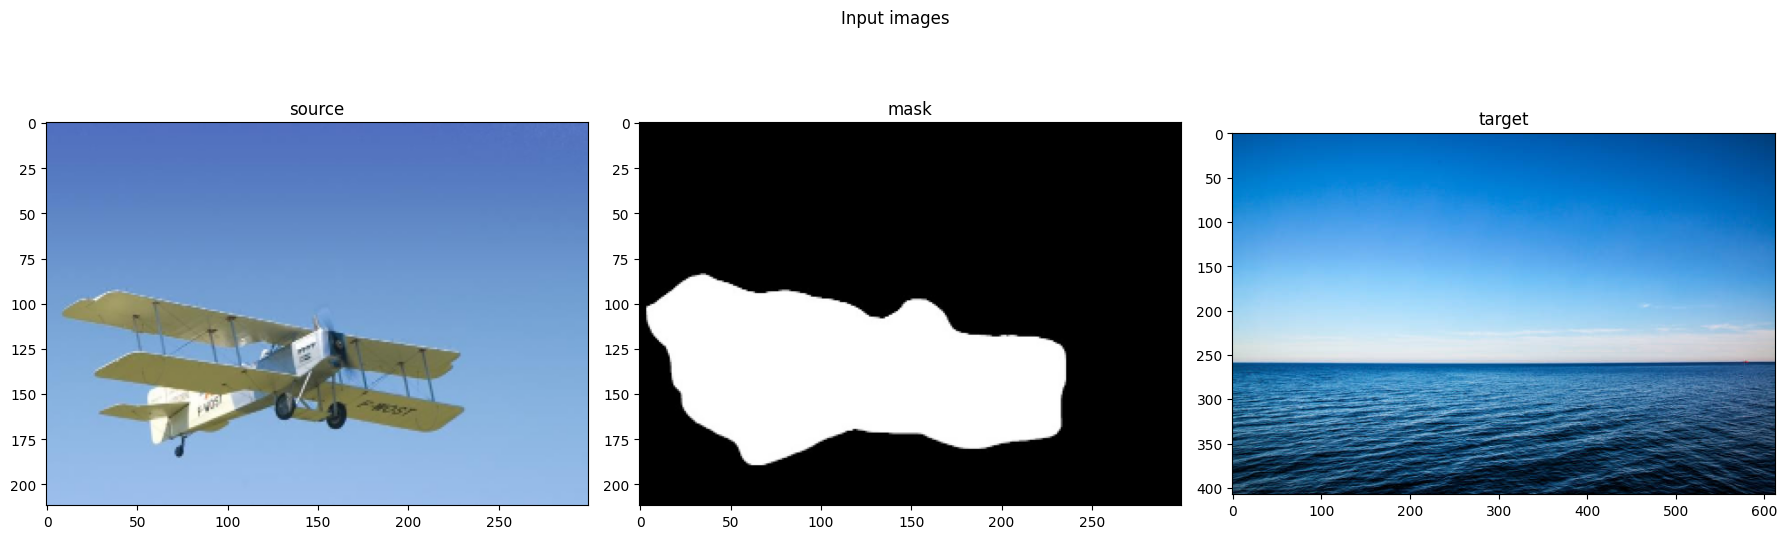

In [2]:
offset, scale = get_offset(IMAGE_NAME)
image = load_img(IMAGE_NAME, target_offset=offset, scale=scale)
display_images(image, title="Input images")

## **Preprocessing**

Source shape: 212x300
Target shape: 408x612
Offset (Ho, Wo): (43, 54)
Target region: H[43:255] W[54:354]


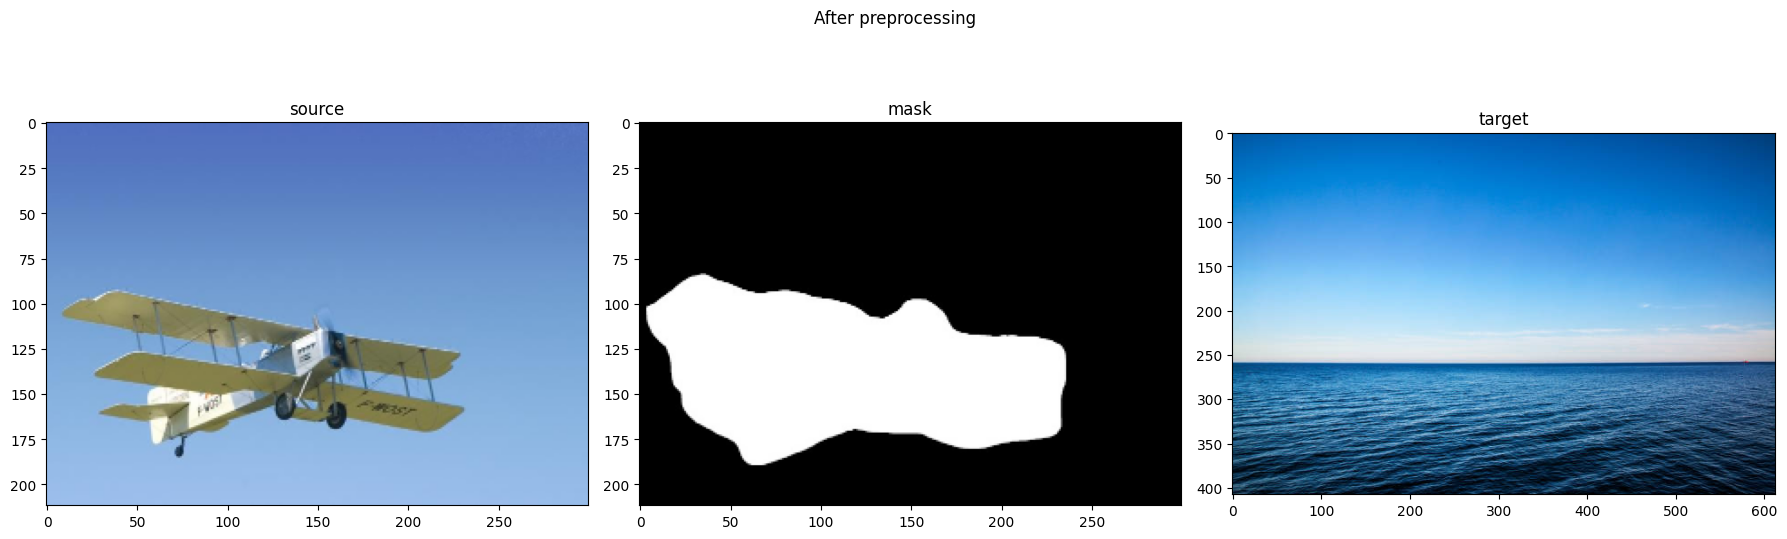

In [3]:
data = preprocess_images(image)
display_images(data, title="After preprocessing")

## **Naive copy**

The simplest approach, paste the source directly onto the target using the mask as an alpha channel:

$$C = \alpha F + (1 - \alpha) B$$

where $F$ is the source (foreground), $B$ is the target (background), and $\alpha \in [0, 1]$ is the mask value at each pixel.

No gradient information is used. The result preserves the source colours exactly, which means any colour or brightness difference between source and target will appear as a hard seam at the mask boundary.

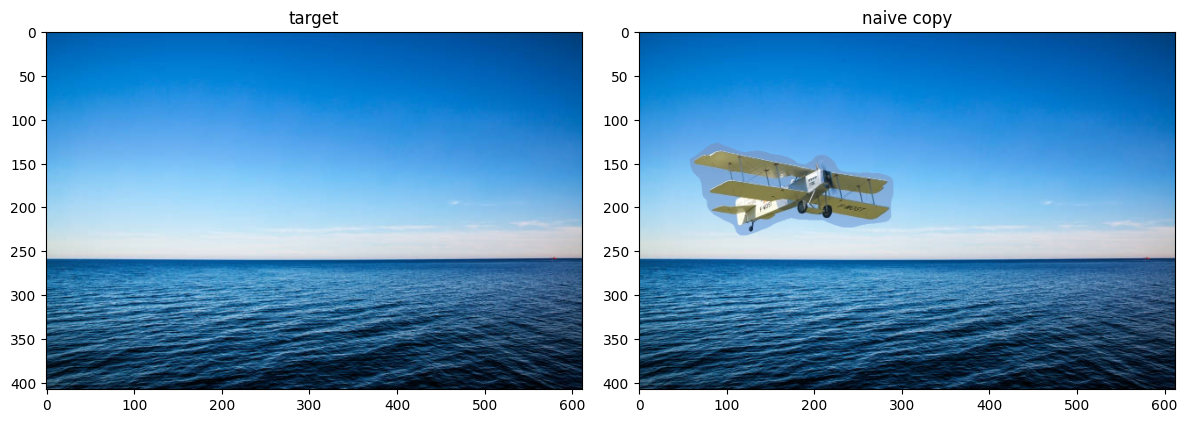

In [4]:
result_naive = naive_blend(data)
display_images({"target": data["target"], "naive copy": result_naive})

## **Laplacian Blending**

### ***Mathematical Background***

Consider a Linear Time-Invariant (LTI) system with input $x(t)$ and output $y(t)$. We want to find a general formula relating the two — without assuming any specific form of $x(t)$.

The system satisfies two properties:

- **Linearity**: if $x_1(t) \to y_1(t)$ and $x_2(t) \to y_2(t)$, then $ax_1(t) + bx_2(t) \to ay_1(t) + by_2(t)$
- **Time-invariance**: if $x(t) \to y(t)$, then $x(t - \tau) \to y(t - \tau)$

The Dirac delta $\delta(t)$ has the sifting property:

$$\int_{-\infty}^{\infty} f(t)\, \delta(t - \tau)\, d\tau = f(t)$$

which means any signal can be written as a continuous weighted sum of shifted impulses:

$$x(t) = \int_{-\infty}^{\infty} x(\tau)\, \delta(t - \tau)\, d\tau$$

Intuitively: $x(t)$ is decomposed into infinitely many impulses, each placed at time $\tau$ with amplitude $x(\tau)$.

Define the **impulse response** $h(t)$ as the system's output when the input is $\delta(t)$:

$$\delta(t) \xrightarrow{\text{system}} h(t)$$

By time-invariance, a shifted impulse produces a shifted response:

$$\delta(t - \tau) \xrightarrow{\text{system}} h(t - \tau)$$

Since $x(t)$ is a weighted sum of shifted impulses, and the system is linear, the output is the same weighted sum of shifted impulse responses:

$$y(t) = \int_{-\infty}^{\infty} x(\tau)\, h(t - \tau)\, d\tau$$

This integral is the definition of convolution:

$$y(t) = (x * h)(t) = \int_{-\infty}^{\infty} x(\tau)\, h(t - \tau)\, d\tau$$

The output of any LTI system is fully determined by its impulse response $h$. Knowing $h$ is sufficient to predict the system's behaviour for any input.

In the image domain, signals are discrete and 2D. The convolution of image $I$ with kernel $g$ at pixel $(x, y)$ is:

$$(I * g)(x, y) = \sum_{m} \sum_{n} I(x - m,\, y - n)\, g(m, n)$$

This is equivalent to sliding the kernel over the image and computing a weighted sum of neighbouring pixels at each location. When $g$ is a Gaussian kernel, the result is a blurred version of $I$ — high-frequency components (edges, noise) are suppressed, low-frequency components (smooth regions) are preserved.

### ***The Gaussian Kernel***

The continuous Gaussian function in 2D is:

$$G_\sigma(x, y) = \frac{1}{2\pi\sigma^2} \exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

For pyramid construction, a simple discrete approximation using a 3×3 kernel is (but I use 5×5 in my code):

$$g = \frac{1}{16}\begin{bmatrix} 1&2&1\\2&4&2\\1&2&1 \end{bmatrix}$$

which is separable, the 2D Gaussian factors into the product of two 1D Gaussians:

$$G_\sigma(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}} = \left(\frac{1}{\sqrt{2\pi}\,\sigma} e^{-\frac{x^2}{2\sigma^2}}\right)\cdot\left(\frac{1}{\sqrt{2\pi}\,\sigma} e^{-\frac{y^2}{2\sigma^2}}\right) = G_\sigma(x) \cdot G_\sigma(y)$$

Because of this, convolving with $G_\sigma$ in 2D is equivalent to convolving with $G_\sigma(x)$ along rows and then $G_\sigma(y)$ along columns. The discrete kernel $g$ inherits this property and can be written as the outer product of a 1D kernel with itself:

$$g = \frac{1}{4}\begin{bmatrix}1\\2\\1\end{bmatrix} \cdot \frac{1}{4}\begin{bmatrix}1&2&1\end{bmatrix}$$

Separability is important for efficiency: convolving a $H \times W$ image with a $k \times k$ kernel costs $O(HWk^2)$ operations, but applying two 1D convolutions sequentially costs only $O(HWk)$.

The Gaussian kernel has a key property: repeated convolution with $g$ is equivalent to convolving once with a wider Gaussian:

$$g * g * \cdots * g\ (k \text{ times}) = g^{(k)}$$

where $g^{(k)}$ approximates a Gaussian with $\sigma_k = \sqrt{k}\,\sigma$. Each additional convolution broadens the blur and removes more high-frequency content.

### ***Gaussian Pyramid***

The Gaussian pyramid $\{G_0, G_1, \ldots, G_N\}$ is built by alternating convolution and downsampling.

Recall the definition of 2D discrete convolution:

$$(I * g)(x, y) = \sum_m \sum_n g(m, n) \cdot I(x + m,\, y + n)$$

At each output pixel $(x, y)$, the kernel $g$ is placed over the image centred at that location, and the result is a weighted sum of the neighbouring pixels, with weights determined by $g$. When $g$ is a Gaussian kernel, nearby pixels contribute more than distant ones, producing a smoothed (blurred) output.

Setting $G_0 = I$, each subsequent level applies this convolution and then keeps only the even-indexed pixels:

$$G_k(x, y) = (G_{k-1} * g)(2x,\, 2y) = \sum_m \sum_n g(m, n) \cdot G_{k-1}(2x + m,\, 2y + n)$$

equivalently,
$$\text{pyrDown}(G_{k-1})(x, y) = \sum_m \sum_n g(m, n) \cdot G_{k-1}(2x + m,\, 2y + n)$$

The factor of 2 in the arguments means we evaluate the convolved image only at positions $(0,0), (0,2), (2,0), (2,2), \ldots$, every other row and column is discarded. The convolution step before subsampling is mandatory: halving the resolution halves the Nyquist frequency, so any frequency above that limit must be removed first. Without it, those frequencies would fold back and corrupt the lower frequencies of $G_k$, an artefact known as aliasing.

By induction, $G_k$ is equivalent to convolving the original image with a Gaussian of width $\propto 2^k$:

$$G_k \approx I * g^{(2^k)}$$

Each level is half the spatial resolution of the previous. The pyramid represents the image at progressively coarser scales, discarding finer details at each step.


### ***Laplacian Pyramid***

The Gaussian pyramid is a low-pass representation, each level retains less and less detail. To recover what was lost at each step, we define the **Laplacian pyramid**.

The upsampling operator $\text{pyrUp}$ is the approximate inverse of $\text{pyrDown}$. Starting from a coarse image $G_{k+1}$, the first step is to double the spatial dimensions by inserting a zero between every pair of adjacent pixels:

$$\tilde{G}_{k+1}(x, y) = \begin{cases} G_{k+1}\!\left(\dfrac{x}{2},\, \dfrac{y}{2}\right) & \text{if } x \text{ and } y \text{ are both even} \\ 0 & \text{otherwise} \end{cases}$$

$\tilde{G}_{k+1}$ now has the right dimensions, but three quarters of its pixels are zero and carry no information. We apply convolution with $g$ to fill them in, each zero pixel receives a weighted average of its non-zero neighbours:

$$(\tilde{G}_{k+1} * g)(x, y) = \sum_m \sum_n g(m, n) \cdot \tilde{G}_{k+1}(x + m,\, y + n)$$

Because only one in four pixels in $\tilde{G}_{k+1}$ is non-zero, the convolution sum is on average $\frac{1}{4}$ of what it would be on a fully populated grid. To restore the correct intensity, we scale by 4:

$$\text{pyrUp}(G_{k+1})(x, y) = 4 \sum_m \sum_n g(m, n) \cdot \tilde{G}_{k+1}(x + m,\, y + n)$$

The result is a smoothly interpolated image at twice the resolution of $G_{k+1}$, though it is not a perfect reconstruction of $G_k$, the convolution in $\text{pyrDown}$ irreversibly discarded high-frequency content. This is precisely why the Laplacian pyramid stores the residuals explicitly. The $k$-th Laplacian level is the difference between the current Gaussian level and the upsampled next level:

$$L_k = G_k - \text{pyrUp}(G_{k+1})$$

$L_k$ captures the detail, the band of frequencies present in $G_k$ but absent in $G_{k+1}$. It is a **band-pass filter** output: it retains only the frequencies between scale $k$ and scale $k+1$.

The coarsest level is kept as-is:

$$L_N = G_N$$

**Perfect reconstruction.** The Laplacian pyramid is a lossless decomposition. The original image is recovered by the recurrence:

$$G_k = L_k + \text{pyrUp}(G_{k+1})$$

Starting from $G_N = L_N$ and collapsing upward:

$$I = G_0 = L_0 + \text{pyrUp}\!\Big(L_1 + \text{pyrUp}\!\big(L_2 + \cdots\big)\Big)$$

No information is discarded, the Laplacian pyramid is an invertible, overcomplete representation of the image. This property is what makes it suitable for blending: we can manipulate each frequency band independently and then reconstruct a coherent result.

### ***Blending in the Frequency Domain***

Naive blending applies a hard or soft mask directly to pixel values. The problem is that the mask boundary is a single edge that affects all frequencies equally, a sharp transition at fine scales produces visible seams, while a soft transition at coarse scales blurs details.

Laplacian blending resolves this by blending each frequency band with a mask that is appropriate for that scale.

**Mask pyramid.** The mask $M_0$ is downsampled through the same Gaussian pyramid:

$$M_k = (M_0 * g^{(2^k)}) \downarrow_2^k$$

Because each level applies additional Gaussian blur, $M_k$ becomes progressively softer as $k$ increases. At the coarsest level, the mask is so blurred that there is no longer a sharp boundary, only a smooth gradient across the blending region.

**Per-level blending.** At each pyramid level $k$, blend the source and target Laplacian bands using $M_k$:

$$\boxed{\tilde{L}_k = M_k \cdot L_k^S + (1 - M_k) \cdot L_k^T}$$

This is a spatially-varying weighted average, where the weights are determined by the blurred mask at that scale. The blending is applied independently at every frequency band.

**Reconstruction.** The blended image is recovered by collapsing the blended pyramid:

$$\tilde{I} = \tilde{L}_0 + \text{pyrUp}\!\Big(\tilde{L}_1 + \text{pyrUp}\!\big(\tilde{L}_2 + \cdots\big)\Big)$$

**Why this works.** The core insight is the scale–sharpness correspondence of the mask pyramid $M_k = M_0 * g^{(2^k)}$:

- **Coarse levels** (large $k$): $M_k$ is heavily blurred, the mask boundary spreads over many pixels, producing an extremely smooth colour transition. This eliminates the global colour mismatch between source and target.
- **Fine levels** (small $k$): $M_k$ is close to the original binary mask, the boundary is sharp, preserving the source's high-frequency details (edges, texture) right up to the mask edge.

Each frequency band is blended with a mask whose sharpness matches the spatial scale of that band. The result inherits smooth low-frequency colour from the coarse levels and crisp high-frequency detail from the fine levels, a trade-off that naive copy cannot achieve with a single uniform mask.

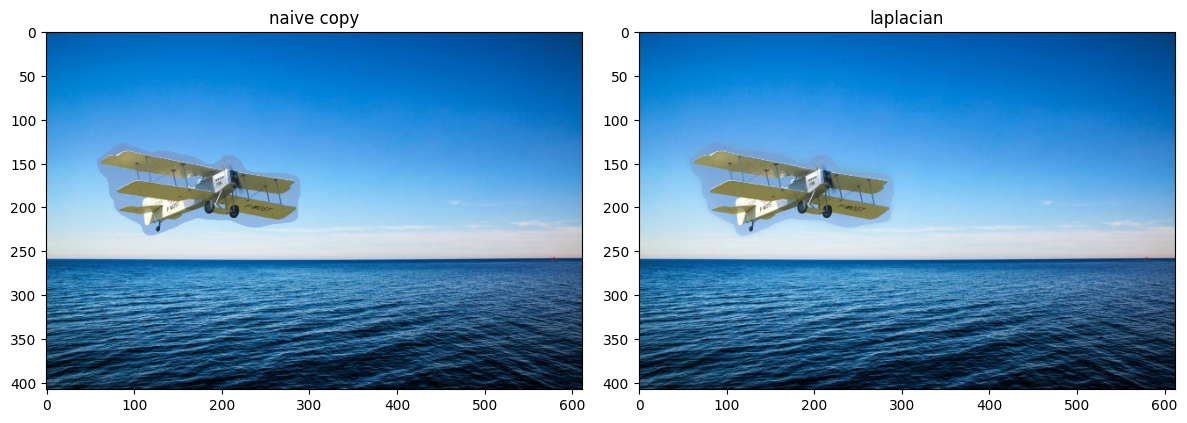

In [5]:
result_laplacian = laplacian_blend(data, num_levels=NUM_LEVELS)
display_images({"naive copy": result_naive, "laplacian": result_laplacian})

## **Poisson Blending**

### ***Motivation***

The core idea behind Poisson blending is that an image can be fully encoded not by its pixel values, but by its **gradients** — the differences between adjacent pixels — together with a set of boundary conditions.

In one dimension, the gradient between adjacent pixels $p$ and $q$ is defined as:

$$v_{p,q} = f_p - f_q$$

Given all gradients within a region and the pixel values at its boundary, the interior pixel values can be uniquely recovered. This is the key insight: if we take the gradients from the source image but enforce the boundary conditions from the target image, the recovered image will preserve the structure (edges, texture) of the source while adapting its colour to match the surrounding target — eliminating visible seams.

### ***Energy Formulation***

For each pair of adjacent pixels $p$ and $q$ inside the mask region $\Omega$, we want the difference $f_p - f_q$ to be as close as possible to the guidance gradient $v_{p,q}$. Summing the squared deviation over all adjacent pairs gives the energy function:

$$h(\mathbf{f}) = \sum_{(p,q) \in \Omega} (f_p - f_q - v_{p,q})^2$$

Minimising $h$ finds the pixel values $\mathbf{f}$ that best preserve the source gradients inside the mask. Since $h$ is quadratic in $\mathbf{f}$, the minimum is found by taking the partial derivative with respect to each unknown pixel $f_p$ and setting it to zero. For an interior pixel $p$ with neighbours $\mathcal{N}(p)$:

$$\frac{\partial h}{\partial f_p} = 0 \implies |\mathcal{N}(p)|\, f_p - \sum_{q \in \mathcal{N}(p)} f_q = \sum_{q \in \mathcal{N}(p)} v_{p,q}$$

where $|\mathcal{N}(p)|$ is the number of neighbours of $p$. Pixels on the boundary of $\Omega$ have at least one neighbour in the target image — their known values move to the right-hand side.

### ***Discretisation***

In a 2D image of width $W$, each pixel $i$ has up to four neighbours: $i-1$, $i+1$, $i-W$, $i+W$. The continuous Laplacian $\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$ discretises using finite differences.

The first-order discrete derivative in $x$:

$$\frac{\partial f}{\partial x} \approx f(i+1) - f(i)$$

Applying it twice gives the second-order derivative:

$$\frac{\partial^2 f}{\partial x^2} \approx [f(i+1) - f(i)] - [f(i) - f(i-1)] = f(i+1) - 2f(i) + f(i-1)$$

Similarly in $y$:

$$\frac{\partial^2 f}{\partial y^2} \approx f(i+W) - 2f(i) + f(i-W)$$

Summing both:

$$\nabla^2 f(i) = -4f(i) + f(i-1) + f(i+1) + f(i-W) + f(i+W)$$

Setting the energy gradient to zero is equivalent to the discrete Poisson equation $\nabla^2 f = \text{div}(\mathbf{v})$, which rearranges to one row of a linear system:

$$\boxed{4f(i) - f(i-1) - f(i+1) - f(i-W) - f(i+W) = \text{div}(\mathbf{v}_i)}$$

### ***The Linear System $\mathbf{Lf} = \mathbf{b}$***

Writing the equation above for every pixel inside $\Omega$ simultaneously yields the sparse linear system:

$$\mathbf{L}\mathbf{f} = \mathbf{b}$$

where:

- $\mathbf{L}$ is the sparse discrete Laplacian matrix, each row has $4$ on the diagonal and $-1$ at the positions of the four neighbours (with boundary neighbour entries removed and their known values absorbed into $\mathbf{b}$)
- $\mathbf{f}$ is the vector of unknown pixel values inside $\Omega$
- $\mathbf{b}$ is the right-hand side: $\text{div}(\mathbf{v}_i)$ for interior pixels, with target boundary values added for pixels adjacent to $\partial\Omega$

The system is solved independently per colour channel. Because $\mathbf{L}$ is sparse and symmetric positive definite, it can be solved efficiently using `scipy.sparse.linalg.spsolve`.

### ***Mixed Gradients***

In the standard formulation, the guidance field $\mathbf{v}$ is taken entirely from the source image. An extension is to use mixed gradients at each pixel, take whichever of the source or target gradient has larger magnitude:

$$v_{p,q} = \begin{cases} f^S_p - f^S_q & \text{if } |f^S_p - f^S_q| \geq |f^T_p - f^T_q| \\ f^T_p - f^T_q & \text{otherwise} \end{cases}$$

This preserves strong target features (such as textures) that might otherwise be overwritten by a near-flat source region, and gives better results when the source background is not uniform.

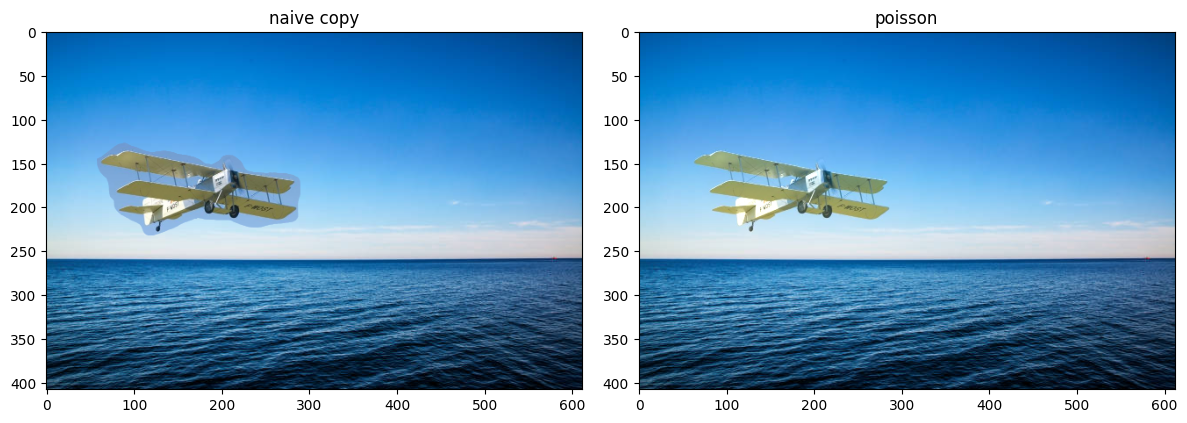

In [6]:
result_poisson = poisson_blend(data, grad_mix=False)
display_images({"naive copy": result_naive, "poisson": result_poisson})

## **Save results**

In [7]:
RESULT_DIR.mkdir(parents=True, exist_ok=True)

def save(img, suffix):
    stem = Path(IMAGE_NAME).stem
    path = RESULT_DIR/ f"{stem}_{suffix}.jpg"
    cv2.imwrite(str(path), (np.clip(img, 0, 1) * 255).astype(np.uint8), [cv2.IMWRITE_JPEG_QUALITY, 95])
    print(f"Save at {path}")

save(result_naive, "naive")
save(result_laplacian, "laplacian")
save(result_poisson, "poisson")


Save at C:\Users\ASUS\Downloads\ALL_PROJECT\Blending_Image\data\result\03_naive.jpg
Save at C:\Users\ASUS\Downloads\ALL_PROJECT\Blending_Image\data\result\03_laplacian.jpg
Save at C:\Users\ASUS\Downloads\ALL_PROJECT\Blending_Image\data\result\03_poisson.jpg
